In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# EDA Checking for null
df.isna().sum().sum()

np.int64(0)

In [5]:
# No missing values

In [6]:
# Finding correlation
# plt.figure(figsize=(20,20))
# sns.heatmap(df.corr(),annot=True)
order = np.unique(df["label"].sort_values())
order

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [7]:
dfModel = df.copy()


def split_x_and_y(df, target):
    """
    Split into x and y utility function
    """
    X = df[[col for col in df.columns if col != target]]
    y = df[target]
    return X, y


X, y = split_x_and_y(df, "label")

In [8]:
X.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [9]:
from sklearn.preprocessing import scale

X_scaled = scale(X)

In [10]:
X_scaled.shape

(42000, 784)

In [11]:
# Building linear model

# Splitting into training and validation
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, train_size=0.1, random_state=420
)

model_linear = SVC(kernel="linear")

model_linear.fit(X_train, y_train)

# Linear Prediction:

# training predictions
y_linear_train_pred = model_linear.predict(X_train)
# testing predictions
y_linear_test_pred = model_linear.predict(X_test)

In [12]:
from sklearn import metrics

print(f"Train accuracy: {metrics.accuracy_score(y_train, y_linear_train_pred)}")
print(f"Test accuracy: {metrics.accuracy_score(y_test, y_linear_test_pred)}")

Train accuracy: 1.0
Test accuracy: 0.9040211640211641


In [13]:
cm = pd.DataFrame(metrics.confusion_matrix(y_test, y_linear_test_pred), columns=order)
cm

,0,1,2,3,4,5,6,7,8,9
0,3601,0,25,10,8,30,36,1,19,1
1,0,4113,14,16,9,5,6,8,22,6
2,52,49,3318,87,71,15,55,35,56,12
3,11,42,114,3521,10,102,6,20,72,27
4,28,14,58,4,3359,13,16,15,3,148
5,41,27,35,219,37,2894,45,4,90,12
6,45,6,75,4,35,38,3500,1,13,0
7,20,31,94,48,88,12,0,3539,16,154
8,32,90,74,129,23,124,23,29,3103,36
9,32,12,33,40,198,19,1,154,38,3224


In [14]:
cm.describe()

,0,1,2,3,4,5,6,7,8,9
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,386.200000,438.400000,384.000000,407.800000,383.800000,325.200000,368.800000,380.600000,343.200000,362.000000
std,1129.673483,1291.388331,1031.395818,1095.997547,1046.964586,903.495287,1100.356993,1110.677791,970.102492,1007.290425
min,0.000000,0.000000,14.000000,4.000000,8.000000,5.000000,0.000000,1.000000,3.000000,0.000000
25%,22.000000,12.500000,33.500000,11.500000,13.250000,13.500000,6.000000,5.000000,16.750000,7.500000
50%,32.000000,29.000000,66.000000,44.000000,36.000000,24.500000,19.500000,17.500000,30.000000,19.500000
75%,44.000000,47.250000,89.250000,118.500000,83.750000,86.000000,42.750000,33.500000,68.000000,120.000000
max,3601.000000,4113.000000,3318.000000,3521.000000,3359.000000,2894.000000,3500.000000,3539.000000,3103.000000,3224.000000


In [15]:
cm[0].sum()

np.int64(3862)

In [16]:
model_rbf = SVC(kernel="rbf")
model_rbf.fit(X_train, y_train)
rbf_y = model_rbf.predict(X_test)

In [17]:
print(f"RBF accuracy score: {metrics.accuracy_score(y_test, rbf_y)}")

RBF accuracy score: 0.921984126984127


In [18]:
model_rbf.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [19]:
from sklearn.model_selection import KFold, GridSearchCV

# creating a KFold object with 5 splits
# folds = KFold(n_splits=5, shuffle=True, random_state=420)

# specify range of hyperparameters
# Set the parameters by cross-validation
hyper_params = [{"gamma": [1e-2, 1e-3, 1e-4], "C": [1, 10, 100]}]


# specify model
model = SVC(kernel="rbf")

# set up GridSearchCV()
model_cv = GridSearchCV(
    estimator=model,
    param_grid=hyper_params,
    scoring="accuracy",
    verbose=1,
    return_train_score=True,
)

# fit the model
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 100], 'gamma': [0.01, 0.001, 0.0001]}],
             return_train_score=True, scoring='accuracy', verbose=1)

In [20]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,2.998666,0.042887,0.678801,0.008440,1,0.0100,"{'C': 1, 'gamma': 0.01}",0.722619,0.715476,0.708333,...,0.705714,0.015438,9,1.000000,0.999702,0.999702,1.000000,1.000000,0.999881,0.000146
1,0.937645,0.021166,0.445366,0.002071,1,0.0010,"{'C': 1, 'gamma': 0.001}",0.910714,0.919048,0.892857,...,0.906190,0.008631,3,0.964881,0.962500,0.963095,0.964881,0.965179,0.964107,0.001091
2,1.386632,0.013276,0.593057,0.004975,1,0.0001,"{'C': 1, 'gamma': 0.0001}",0.878571,0.865476,0.858333,...,0.871429,0.008650,6,0.893750,0.893750,0.895536,0.891071,0.894643,0.893750,0.001494
3,3.048973,0.020404,0.688740,0.017716,10,0.0100,"{'C': 10, 'gamma': 0.01}",0.735714,0.733333,0.726190,...,0.724524,0.010952,7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,0.795518,0.004378,0.407652,0.004258,10,0.0010,"{'C': 10, 'gamma': 0.001}",0.920238,0.936905,0.907143,...,0.922857,0.009624,1,0.999107,0.999405,0.999702,0.999702,0.999405,0.999464,0.000223
5,0.644774,0.003629,0.382636,0.006336,10,0.0001,"{'C': 10, 'gamma': 0.0001}",0.920238,0.902381,0.885714,...,0.902619,0.011329,4,0.951488,0.955357,0.955060,0.954762,0.951190,0.953571,0.001835
6,3.126030,0.099703,0.680173,0.008804,100,0.0100,"{'C': 100, 'gamma': 0.01}",0.735714,0.733333,0.726190,...,0.724524,0.010952,7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
7,0.804291,0.007127,0.410462,0.005037,100,0.0010,"{'C': 100, 'gamma': 0.001}",0.920238,0.935714,0.909524,...,0.922619,0.008418,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
8,0.519629,0.015714,0.325532,0.006097,100,0.0001,"{'C': 100, 'gamma': 0.0001}",0.900000,0.909524,0.889286,...,0.899762,0.006793,5,0.996726,0.995833,0.996429,0.997024,0.995833,0.996369,0.000476


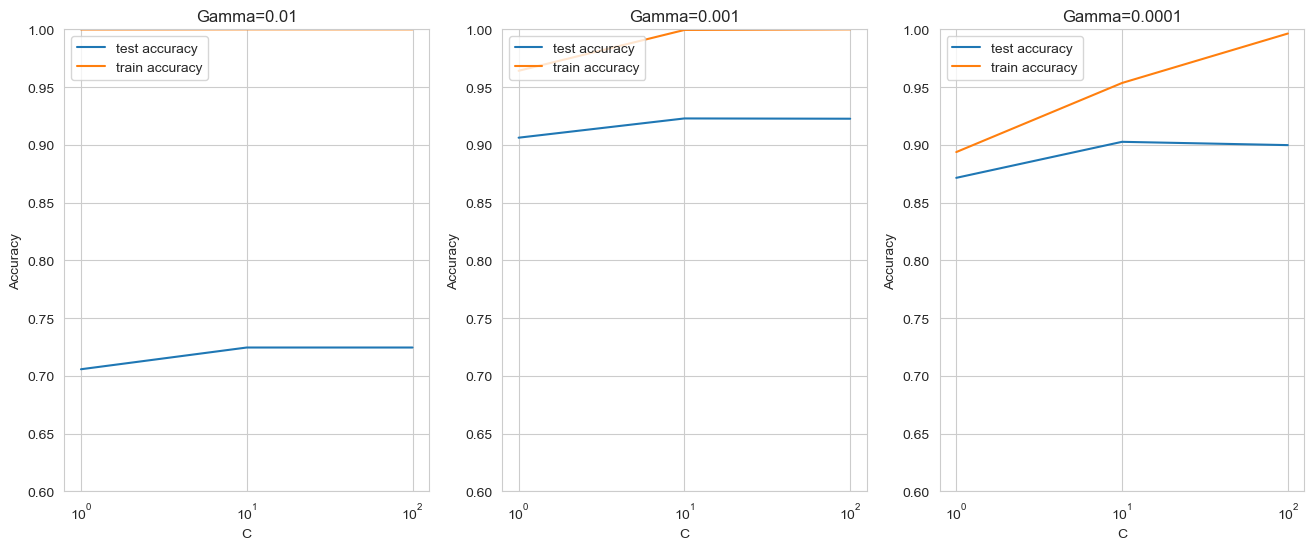

In [21]:
# converting C to numeric type for plotting on x-axis

cv_results["param_C"] = cv_results["param_C"].astype("int")

# # plotting
plt.figure(figsize=(16, 6))

# subplot 1/3
plt.subplot(131)
gamma_01 = cv_results[cv_results["param_gamma"] == 0.01]

plt.plot(gamma_01["param_C"], gamma_01["mean_test_score"])
plt.plot(gamma_01["param_C"], gamma_01["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.01")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")

# subplot 2/3
plt.subplot(132)
gamma_001 = cv_results[cv_results["param_gamma"] == 0.001]

plt.plot(gamma_001["param_C"], gamma_001["mean_test_score"])
plt.plot(gamma_001["param_C"], gamma_001["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.001")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")


# subplot 3/3
plt.subplot(133)
gamma_0001 = cv_results[cv_results["param_gamma"] == 0.0001]

plt.plot(gamma_0001["param_C"], gamma_0001["mean_test_score"])
plt.plot(gamma_0001["param_C"], gamma_0001["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.0001")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")

In [22]:
import cv2

four = df.iloc[3, 1:]
four.shape

(784,)

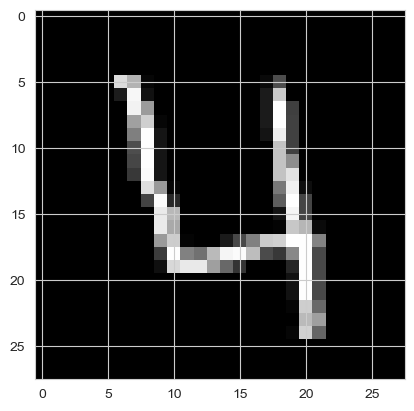

In [23]:
four = four.values.reshape(28, 28)
plt.imshow(four, cmap="gray")

In [24]:
best_score = model_cv.best_score_
best_hyperparams = model_cv.best_params_
best_score, best_hyperparams

(np.float64(0.9228571428571429), {'C': 10, 'gamma': 0.001})

In [25]:
# Final Model
best_C = best_hyperparams["C"]
best_gamma = best_hyperparams["gamma"]

svm_final = SVC(kernel="rbf", C=best_C, gamma=best_gamma)
svm_final.fit(X_train, y_train)

SVC(C=10, gamma=0.001)

In [26]:
y_final_pred = svm_final.predict(X_test)

In [27]:
print(f"Accuracy: {metrics.accuracy_score(y_test, y_final_pred)}")

Accuracy: 0.931058201058201


In [28]:
print(metrics.classification_report(y_test, y_final_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3731
           1       0.96      0.98      0.97      4199
           2       0.84      0.94      0.88      3750
           3       0.92      0.91      0.91      3925
           4       0.93      0.94      0.93      3658
           5       0.94      0.91      0.92      3404
           6       0.96      0.95      0.95      3717
           7       0.95      0.91      0.93      4002
           8       0.95      0.89      0.92      3663
           9       0.93      0.90      0.92      3751

    accuracy                           0.93     37800
   macro avg       0.93      0.93      0.93     37800
weighted avg       0.93      0.93      0.93     37800



In [29]:
# Final Check
test_data = pd.read_csv("test.csv")

In [30]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
test_X = scale(test_data)

In [32]:
test_final = svm_final.predict(test_X)

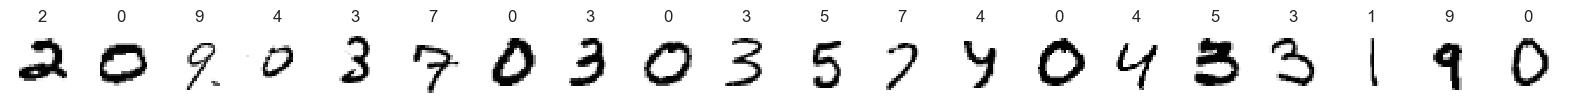

In [33]:
first = test_data.loc[0, :]
_, axes = plt.subplots(nrows=1, ncols=20, figsize=(20, 3))
i = 0
for ax, image, label in zip(axes, test_data, test_final):
    ax.set_axis_off()
    image = test_data.iloc[i, :]
    # image = image.values.reshape
    image = image.values.reshape(28, 28)
    # print(image.shape)
    ax.imshow(image, cmap=plt.cm.grey_r, interpolation="nearest")
    ax.set_title(label)
    i += 1
#
# first = first.values.reshape(28, 28)
# plt.imshow(first, cmap="gray")

In [34]:
test_final[:9]

array([2, 0, 9, 4, 3, 7, 0, 3, 0])

In [35]:
test_data.iloc[0, :].shape

(784,)